# Modelos Avanzados - Random Forest y XGBoost

En este cuaderno buscaremos mejorar el rendimiento del modelo baseline (Regresión Logística) utilizando algoritmos de ensamble más potentes.

Evaluaremos:
1.  **Random Forest Classifier**
2.  **XGBoost Classifier**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos nuevos
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score
)

## 1. Carga y Preparación de Datos
Reutilizamos la misma lógica de carga que en el notebook anterior.

In [11]:
df_sample = pd.read_csv("../data/processed/df_sample.csv")

# Definir target
if "target_bad" in df_sample.columns:
    target_col = "target_bad"
else:
    raise ValueError("Falta target_bad")

# Excluir leaks y identifiers
leak_cols = [
    "loan_status", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", 
    "total_rec_int", "total_rec_late_fee", "recoveries", 
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt", 
    "next_pymnt_d", "last_credit_pull_d", "out_prncp", "out_prncp_inv"
]
id_text_cols = ["id", "member_id", "url", "desc", "emp_title", "title"]

leak_cols = [c for c in leak_cols if c in df_sample.columns]
id_text_cols = [c for c in id_text_cols if c in df_sample.columns]

X_cols = [c for c in df_sample.columns if c not in ([target_col] + id_text_cols + leak_cols)]

# Eliminar NaNs en target
df_model = df_sample.dropna(subset=[target_col]).copy()

# Split
X = df_model[X_cols]
y = df_model[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y
)

print(f"Train shape: {X_train.shape}")

Train shape: (106704, 54)


## 2. Pipeline de Preprocesamiento
Para modelos de árboles (RF, XGB) el escalado no es estrictamente necesario, pero el OneHotEncoding sí es requerido para variables categóricas (especialmente en Sklearn).

In [12]:
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

# Imputación básica para árboles
num_pipe = SimpleImputer(strategy="median")

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # sparse=False para facilitar debug si la memoria lo permite
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features)
    ],
    remainder="drop"
)

## 3. Modelo 1: Random Forest
Entrenamos un Random Forest con 100 árboles. Usamos `class_weight='balanced'`.

In [13]:
rf_pipeline = Pipeline(steps=[
    ("process", preprocess),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=123, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

# Evaluación
probs_rf = rf_pipeline.predict_proba(X_test)[:, 1]
preds_rf = (probs_rf >= 0.5).astype(int)

print("Random Forest ROC AUC:", roc_auc_score(y_test, probs_rf))
print(classification_report(y_test, preds_rf))

/Users/mauvilar/.venvs/credit_risk_env/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['annual_inc_joint' 'dti_joint' 'verification_status_joint' 'open_acc_6m'
 'open_il_6m' 'open_il_12m' 'open_il_24m' 'mths_since_rcnt_il'
 'total_bal_il' 'il_util' 'open_rv_12m' 'open_rv_24m' 'max_bal_bc'
 'all_util' 'inq_fi' 'total_cu_tl' 'inq_last_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/mauvilar/.venvs/credit_risk_env/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['annual_inc_joint' 'dti_joint' 'verification_status_joint' 'open_acc_6m'
 'open_il_6m' 'open_il_12m' 'open_il_24m' 'mths_since_rcnt_il'
 'total_bal_il' 'il_util' 'open_rv_12m' 'open_rv_24m' 'max_bal_bc'
 'all_util' 'inq_fi' 'total_cu_tl' 'inq_last_12m']. At least one non-missing value is needed for imputation with strategy='median

Random Forest ROC AUC: 0.7037862385621791
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     21238
           1       0.32      0.65      0.42      5439

    accuracy                           0.64     26677
   macro avg       0.60      0.64      0.58     26677
weighted avg       0.76      0.64      0.68     26677



## 4. Modelo 2: XGBoost
XGBoost suele ser el estándar de la industria. Requiere ajustar `scale_pos_weight` para el desbalance.

In [14]:
# Calcular ratio para scale_pos_weight (negativos / positivos)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(steps=[
    ("process", preprocess),
    ("model", XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1,
        scale_pos_weight=ratio,
        random_state=123,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

# Evaluación
probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
preds_xgb = (probs_xgb >= 0.5).astype(int)

print("XGBoost ROC AUC:", roc_auc_score(y_test, probs_xgb))
print(classification_report(y_test, preds_xgb))

/Users/mauvilar/.venvs/credit_risk_env/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['annual_inc_joint' 'dti_joint' 'verification_status_joint' 'open_acc_6m'
 'open_il_6m' 'open_il_12m' 'open_il_24m' 'mths_since_rcnt_il'
 'total_bal_il' 'il_util' 'open_rv_12m' 'open_rv_24m' 'max_bal_bc'
 'all_util' 'inq_fi' 'total_cu_tl' 'inq_last_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


XGBoost ROC AUC: 0.7177233389951831
              precision    recall  f1-score   support

           0       0.88      0.67      0.76     21238
           1       0.33      0.64      0.44      5439

    accuracy                           0.67     26677
   macro avg       0.61      0.66      0.60     26677
weighted avg       0.77      0.67      0.70     26677



/Users/mauvilar/.venvs/credit_risk_env/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['annual_inc_joint' 'dti_joint' 'verification_status_joint' 'open_acc_6m'
 'open_il_6m' 'open_il_12m' 'open_il_24m' 'mths_since_rcnt_il'
 'total_bal_il' 'il_util' 'open_rv_12m' 'open_rv_24m' 'max_bal_bc'
 'all_util' 'inq_fi' 'total_cu_tl' 'inq_last_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 5. Comparativa de Resultados
Visualizamos las curvas ROC de ambos modelos para decidir cuál es mejor.

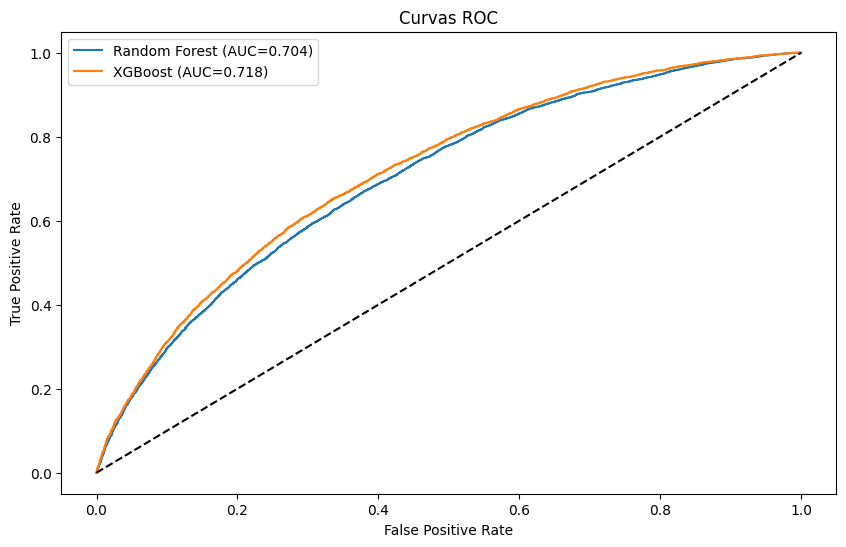

In [15]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs_xgb)

plt.figure(figsize=(10,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, probs_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, probs_xgb):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.show()